q1 .so difference b/w acf and pacf is acf is like direct effect + indirect effect with intervening time points and  <br>
for pacf it is like only direct effect like purely no intervention from the intervening time points.


q2 . The order p is the last significant lag on the PACF plot before it "cuts off" and the subsequent lags become insignificant. <br>
The ACF plot will decrasing continously for AR models and PACF will get sudden sharp cutoff 
<br> which will be knwon as AR(p)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Text(0.5, 0, 'Month')

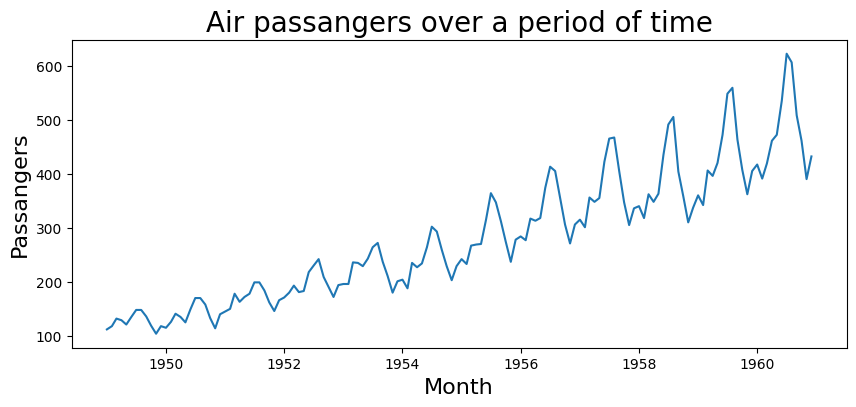

In [15]:
import pandas as pd

df = pd.read_csv('AirPassengers.csv')

# just some data cleaning for making life easier
df.rename(columns={'#Passengers' : 'passengers'},inplace=True)

df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month' , inplace=True)
df.head()

plt.figure(figsize=(10,4))
plt.plot(df.passengers)

plt.title('Air passangers over a period of time',fontsize = 20)

plt.ylabel('Passangers',fontsize = 16)
plt.xlabel('Month',fontsize = 16)



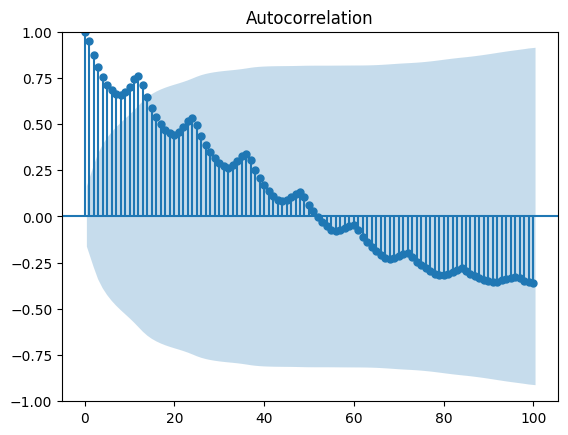

In [16]:
acf = plot_acf(df.passengers,lags = 100)

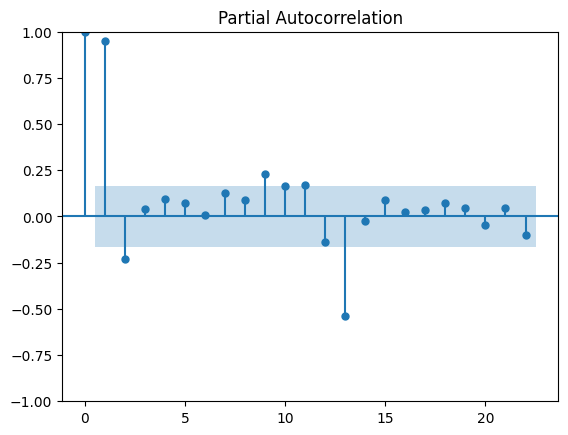

In [18]:
pacf = plot_pacf(df.passengers)

So for the this dataset lag will 2 as after that there is sudden sharp cutoff and afterwards gap become more insignificant . <br>
so we will make AR(2) model for this

In [44]:


x_train = df.loc['1949-01-01':'1959-12-01','passengers'].values
x_test = df.loc['1960-01-01':'1960-12-01','passengers'].values





from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(x_train , lags = 2) # which we got by plotting

model_fit = model.fit()

predict_val = model_fit.predict(start=len(x_train),end=(df.shape[0])-1)


train_indices = np.arange(len(x_train)) 


test_indices = np.arange(len(x_train), len(x_train) + len(x_test))




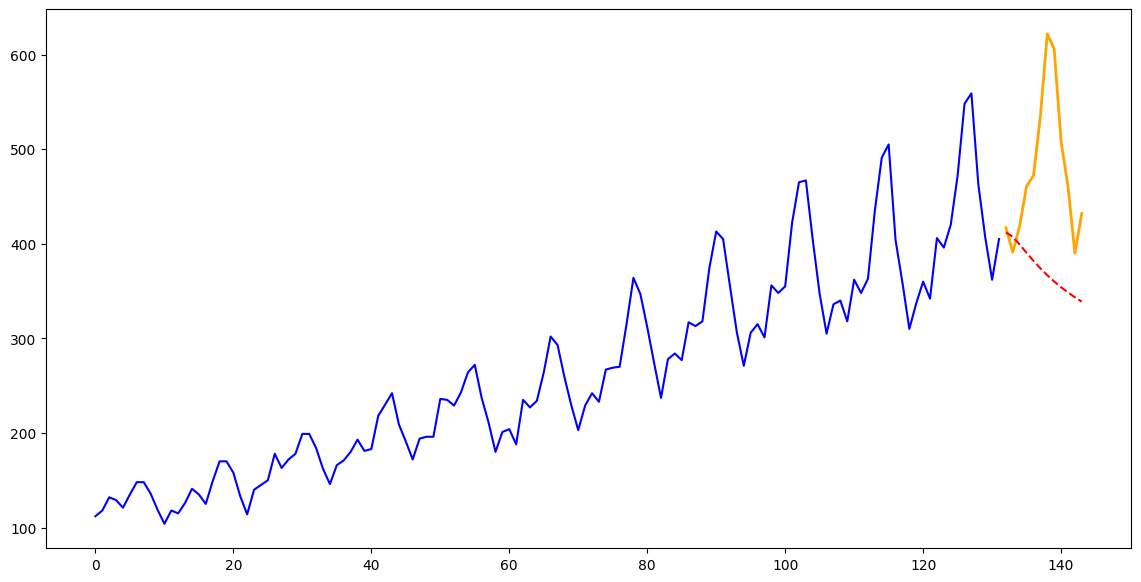

In [46]:
plt.figure(figsize=(14, 7))

# Plot the training data
plt.plot(train_indices,x_train, label='Training Data', color='blue')

# Plot the actual test data
plt.plot(test_indices,x_test, label='Actual Test Data', color='orange', linewidth=2)


# We use the test_series.index to align the predictions correctly on the time axis.
plt.plot(test_indices, predict_val, label='AR(2) Predictions', color='red', linestyle='--')


plt.show()